 ## 1. Data Loading and Exploration 

In [1]:
#  Library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

In [2]:
#  dataset upload
df = pd.read_excel('Telco_Customer_Churn.xlsx')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 2. Data Cleaning and Preprocessing  

In [5]:
# Pre processing

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors='coerce').fillna(0, downcast='infer')

df.rename(columns={'Churn Label' : 'Churn' 
}, inplace=True)

# Drop unusufull columns
    

df_2 = df.drop(['Country','State','Count','Zip Code','Churn Reason','City','Churn Score','Churn Value','CLTV','CustomerID','Lat Long',
                  'Latitude','Longitude'], axis=1)
df_2.dropna(inplace=True)


df_2['Churn'] = df_2['Churn'].map({'Yes': 1, 'No': 0})





## 3. Feature Engineering 

In [6]:
# Encoding object variables
df_encoded = pd.get_dummies(df_2, drop_first=False)

In [7]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn,Gender_Female,Gender_Male,Senior Citizen_No,Senior Citizen_Yes,Partner_No,Partner_Yes,...,Streaming Movies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,Paperless Billing_No,Paperless Billing_Yes,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,0,1,1,0,1,0,...,0,1,0,0,0,1,0,0,0,1
1,2,70.70,151.65,1,1,0,1,0,1,0,...,0,1,0,0,0,1,0,0,1,0
2,8,99.65,820.50,1,1,0,1,0,1,0,...,1,1,0,0,0,1,0,0,1,0
3,28,104.80,3046.05,1,1,0,1,0,0,1,...,1,1,0,0,0,1,0,0,1,0
4,49,103.70,5036.30,1,0,1,1,0,1,0,...,1,1,0,0,0,1,1,0,0,0


## 4. Model Training and Evaluation

In [8]:
#  Split X e y

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [9]:
#  Train/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [10]:
#  Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
#  Model Analysis
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1525
           1       0.65      0.52      0.58       588

    accuracy                           0.79      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.78      0.79      0.78      2113

[[1357  168]
 [ 280  308]]
ROC AUC: 0.8403440392550463


## 5. Threshold Tuning and Final Model 

#### 5.1 Enhance model accuracy in identifying customers likely to churn (Class 1)

In [12]:
# Balancing
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [13]:
#hyperparameters


param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

rsearch = RandomizedSearchCV(RandomForestClassifier(random_state=42), 
                             param_distributions=param_dist,
                             n_iter=20,
                             cv=3,
                             scoring='f1',
                             verbose=1,
                             n_jobs=-1)

rsearch.fit(X_train, y_train)
best_model = rsearch.best_estimator_

print("The best configuration:", rsearch.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
The best configuration: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}


In [14]:
columns_used = X_train.columns

X_test_aligned = X_test[columns_used]

In [15]:
y_pred = best_model.predict(X_test_aligned)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test_aligned)[:,1]))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1525
           1       0.59      0.77      0.67       588

    accuracy                           0.79      2113
   macro avg       0.74      0.78      0.75      2113
weighted avg       0.81      0.79      0.79      2113

[[1207  318]
 [ 136  452]]
ROC AUC: 0.8623374595739937


#### 5.2 Testing XGBoster and LightGBM Model

In [16]:
# Training Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Forecast
y_pred_xgb = xgb_model.predict(X_test_aligned)
y_prob_xgb = xgb_model.predict_proba(X_test_aligned)[:,1]

# Analysis
print("XGBoost Results")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

C:\Users\vankr\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [19:03:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Results
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1525
           1       0.64      0.56      0.60       588

    accuracy                           0.79      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.78      0.79      0.78      2113

[[1335  190]
 [ 256  332]]
ROC AUC: 0.8365807962529275


In [17]:
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test_aligned)
y_prob_lgb = lgb_model.predict_proba(X_test_aligned)[:,1]

print("LightGBM Results")
print(classification_report(y_test, y_pred_lgb))
print(confusion_matrix(y_test, y_pred_lgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1281, number of negative: 3649
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 4930, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.259838 -> initscore=-1.046812
[LightGBM] [Info] Start training from score -1.046812
LightGBM Results
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1525
           1       0.66      0.58      0.62       588

    accuracy                           0.80      2113
   macro avg       0.75      0.73      0.74      2113
weighted avg       0.79      0.80      0.80      2113

[[1351  174]
 [ 249  3

C:\Users\vankr\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [19:03:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1281, number of negative: 3649
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000927 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 4930, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.259838 -> initscore=-1.046812
[LightGBM] [Info] Start training from score -1.046812


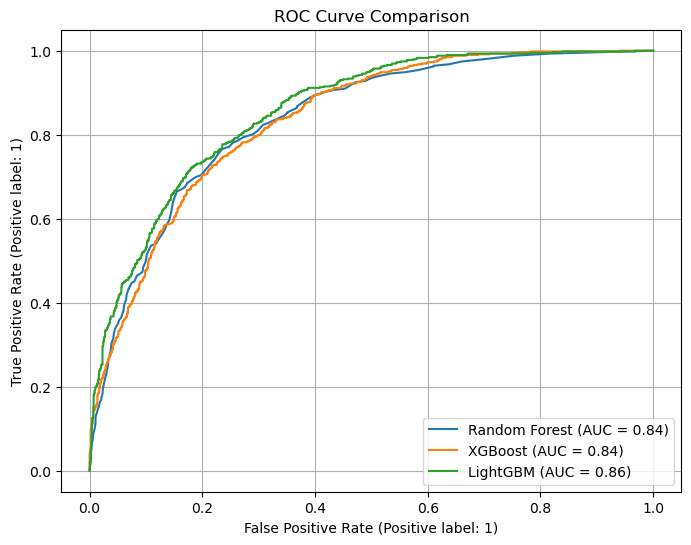

In [18]:
# Trainning Models
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
lgb = LGBMClassifier(random_state=42)

models = {
    'Random Forest': rf,
    'XGBoost': xgb,
    'LightGBM': lgb
}


results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test_aligned)
    y_prob = model.predict_proba(X_test_aligned)[:,1]

    results[name] = {
        'report': classification_report(y_test, y_pred, output_dict=True),
        'confusion': confusion_matrix(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

# ROC Curve Comparison
plt.figure(figsize=(8, 6))
for name in results:
    RocCurveDisplay.from_predictions(y_test, results[name]['y_prob'], name=name, ax=plt.gca())
plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()

In [19]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
lgbm = lgb.LGBMClassifier(random_state=42)

param_grid = {
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500],
    'min_child_samples': [20, 40, 60],
    'subsample': [0.8, 1.0]
}

In [20]:
grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1281, number of negative: 3649
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 4930, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.259838 -> initscore=-1.046812
[LightGBM] [Info] Start training from score -1.046812


GridSearchCV(cv=5, estimator=LGBMClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [-1, 10, 20],
                         'min_child_samples': [20, 40, 60],
                         'n_estimators': [100, 200, 500],
                         'num_leaves': [31, 50, 70], 'subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=1)

In [21]:
print("The best parameters:")
print(grid.best_params_)

print("The best ROC AUC Score:")
print(grid.best_score_)

The best parameters:
{'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
The best ROC AUC Score:
0.8562135190444788


In [22]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_aligned)
y_proba = best_model.predict_proba(X_test_aligned)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.80      0.96      0.87      1525
           1       0.79      0.36      0.50       588

    accuracy                           0.80      2113
   macro avg       0.79      0.66      0.68      2113
weighted avg       0.79      0.80      0.77      2113

[[1467   58]
 [ 374  214]]
ROC AUC: 0.859596855135497


In [23]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


rf = RandomForestClassifier(random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_


y_pred = best_model.predict(X_test_aligned)
y_proba = best_model.predict_proba(X_test_aligned)[:, 1]


print("Best Params:", random_search.best_params_)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1525
           1       0.70      0.57      0.63       588

    accuracy                           0.81      2113
   macro avg       0.77      0.74      0.75      2113
weighted avg       0.80      0.81      0.81      2113

[[1383  142]
 [ 255  333]]
ROC AUC: 0.8640269878443181


#### 5.3 Final Model

In [24]:
threshold = 0.4
y_pred_thresh = (y_proba >= threshold).astype(int)
print("Adjusted Threshold Results:")
print(classification_report(y_test, y_pred_thresh))
print(confusion_matrix(y_test, y_pred_thresh))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Adjusted Threshold Results:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1525
           1       0.63      0.70      0.67       588

    accuracy                           0.80      2113
   macro avg       0.76      0.77      0.76      2113
weighted avg       0.81      0.80      0.81      2113

[[1285  240]
 [ 174  414]]
ROC AUC: 0.8640269878443181


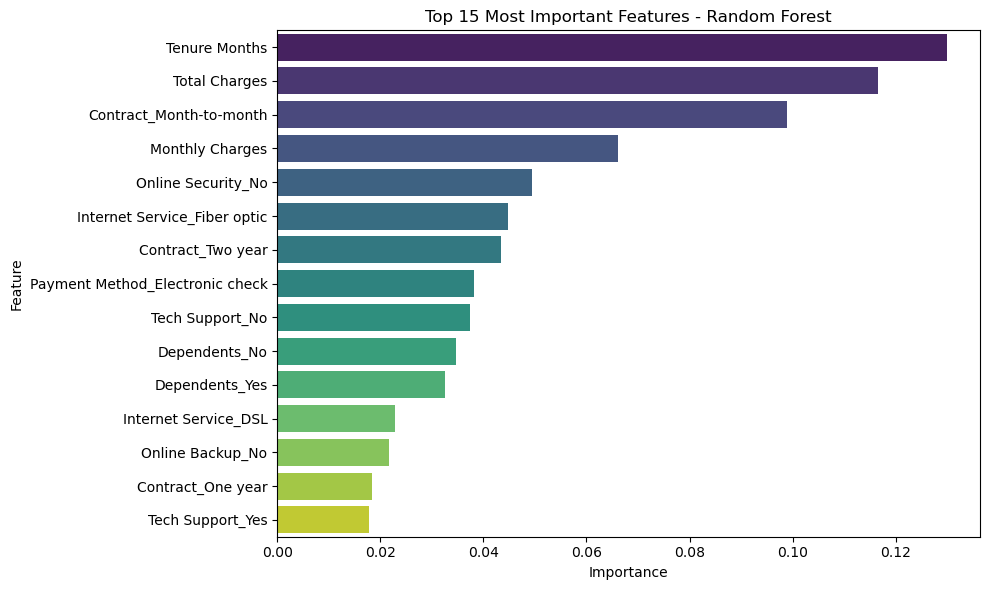

In [25]:
# Feature importances trainning model
importances = best_model.feature_importances_


feature_names = X_train.columns 


feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importances.head(15), palette='viridis')
plt.title('Top 15 Most Important Features - Random Forest')
plt.tight_layout()
plt.show()


## 6. Final Results – Model Predictions (Random Forest)

In [26]:
original_data_test = df.loc[X_test.index, ['CustomerID', 'Contract', 'Monthly Charges', 'Tenure Months']]
original_data_test = original_data_test.reset_index(drop=True)

In [27]:
final_results = pd.DataFrame({
    'CustomerID': original_data_test['CustomerID'],
    'Contract': original_data_test['Contract'],
    'Monthly Charges': original_data_test['Monthly Charges'],
    'Tenure Months': original_data_test['Tenure Months'],
    'prediction': y_pred_thresh,
    'prediction_proba': y_proba
})

In [28]:
# Simulate the DataFrame using real results
display(final_results.sort_values(by='prediction_proba', ascending=False).head(10))


,CustomerID,Contract,Monthly Charges,Tenure Months,prediction,prediction_proba
776,7577-SWIFR,Month-to-month,89.25,1,1,0.897550
1110,0318-QUUOB,Month-to-month,80.55,1,1,0.876648
1943,8603-IJWDN,Month-to-month,86.60,1,1,0.872872
342,7439-DKZTW,Month-to-month,80.55,1,1,0.871139
1807,7216-EWTRS,Month-to-month,100.80,1,1,0.851532
118,8580-AECUZ,Month-to-month,79.10,1,1,0.851059
277,5597-GLBUC,Month-to-month,85.45,1,1,0.849705
1824,1069-XAIEM,Month-to-month,85.05,1,1,0.847346
162,3158-MOERK,Month-to-month,96.00,2,1,0.844660
2057,9248-OJYKK,Month-to-month,76.45,1,1,0.842451


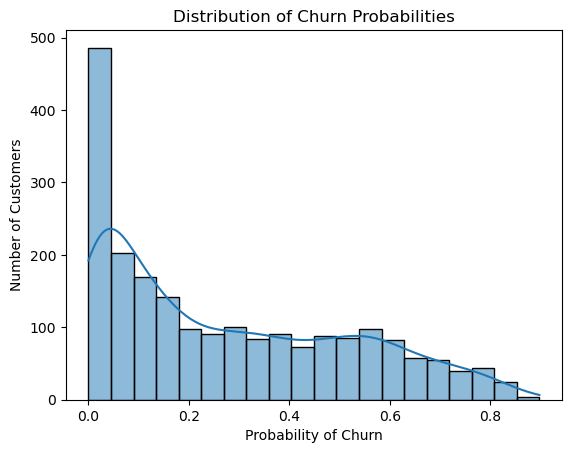

In [29]:
sns.histplot(final_results['prediction_proba'], bins=20, kde=True)
plt.title("Distribution of Churn Probabilities")
plt.xlabel("Probability of Churn")
plt.ylabel("Number of Customers")
plt.show()

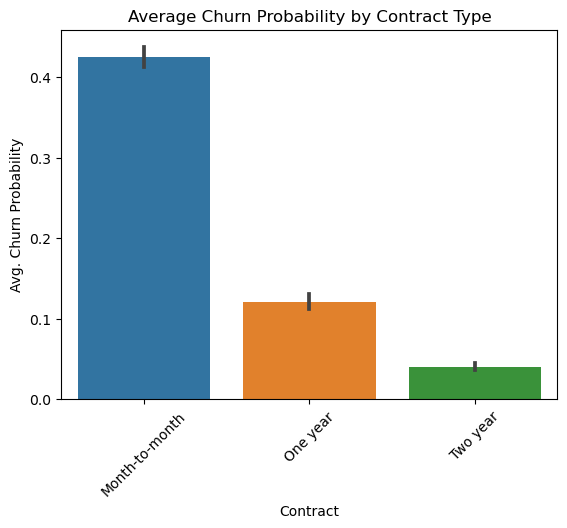

In [30]:
sns.barplot(data=final_results, x='Contract', y='prediction_proba')
plt.title("Average Churn Probability by Contract Type")
plt.ylabel("Avg. Churn Probability")
plt.xticks(rotation=45)
plt.show()

In [31]:
# export final results
final_results.to_csv('churn_predictions.csv', index=False)

### Model Performance Summary

- **Model:** Random Forest (Tuned)
- **Accuracy:** 0.80
- **F1-Score (Churn class):** 0.67
- **Recall (Churn class):** 0.70
- **Precision (Churn class):** 0.63
- **ROC AUC:** 0.86
- **Threshold used:** 0.4

> The model shows a strong ability to distinguish churned customers, especially after threshold adjustment.


###  Business Recommendations

- Encourage longer-term contracts to reduce churn risk.
- Focus retention efforts on customers with high monthly charges and short tenure.
- Integrate churn probability scores into the CRM system for early alerts.

> These insights are derived from the model's prediction patterns and can directly support retention strategies.
